El presente notebook muestra los resultados de la implementación de un modelo de redes neruonales convolucionales donde se emplean filtros de 3x3 y 5x5 en cada capa y se concatenan las salida para la entrada a la capa siguiente

Importación de librerías

In [1]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D, Conv2DTranspose, Concatenate, Activation # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
import matplotlib.pyplot as plt

Funciones

In [2]:
# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)


In [3]:
#Función para visualizar imagenes

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre imágenes de entrada, reales y predichas.

    Parámetros:
        X (numpy array): Entradas (ej. [num_samples, h, w, 1]).
        y (numpy array): Valores reales (targets).
        y_pred (numpy array): Predicciones del modelo.
        n (int): Número de ejemplos a mostrar.
        cmap (str): Mapa de color para mostrar las imágenes.
        titulo_general (str): Título general de la figura.
        xlabel (str): Etiqueta para el eje X.
        ylabel (str): Etiqueta para el eje Y.
    """
    # Ajustar n si es mayor al número de ejemplos disponibles
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)  # título principal arriba

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [4]:
# Directorio con imagenes en tamaño original y tamaño reducido
d_original = 'E:/bandas/banda13/ene_01_mes'
d_reducida = 'E:/bandas/banda13/ene_01_reducida_mes'

# Llamado de función para redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')]) # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]  # Limita los valores al rango [0, 1]

# Parámetro de secuencia temporal
timesteps = 3  # Puedes ajustar este valor

# Construir secuencias para ConvLSTM: X_seq (N, timesteps, H, W, C), y_seq (N, H, W, C)
X_base = np.array(images)[..., np.newaxis]  # (num_imgs, H, W, C)
y_base = X_base.copy()  # y_base igual a X_base, pero se usará para target

N_seq = X_base.shape[0] - timesteps
X_seq = np.array([X_base[i:i+timesteps] for i in range(N_seq)])  # (N_seq, timesteps, H, W, C)
y_seq = y_base[timesteps:]  # (N_seq, H, W, C)

print(f"Forma de X_seq: {X_seq.shape}")  # (N_seq, timesteps, H, W, C)
print(f"Forma de y_seq: {y_seq.shape}")  # (N_seq, H, W, C)

Procesando 741 imágenes
Forma de X_seq: (738, 3, 480, 480, 1)
Forma de y_seq: (738, 480, 480, 1)


Creación de un modelo simple de redes neuronales convolucionales

In [5]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, ConvLSTM2D, Conv2D, TimeDistributed,
    Concatenate, Add, Activation, BatchNormalization
)
from tensorflow.keras.models import Model

# Parámetros
timesteps = 3 # A partir de análisis de correlación
H, W, C = X_seq.shape[2], X_seq.shape[3], X_seq.shape[4]  # (height, width, channels) suponiendo X.shape = (N, T, H, W, C)
semilla = 42
tf.random.set_seed(semilla)

inputs = Input(shape=(timesteps, H, W, C), name='input_sequence')

# === Bloque 1: ConvLSTM multiescala ===
x1_3 = ConvLSTM2D(16, (3, 3), padding='same', return_sequences=True, activation=None)(inputs)
x1_3 = TimeDistributed(BatchNormalization())(x1_3)
x1_3 = Activation('relu')(x1_3)

x1_5 = ConvLSTM2D(16, (5, 5), padding='same', return_sequences=True, activation=None)(inputs)
x1_5 = TimeDistributed(BatchNormalization())(x1_5)
x1_5 = Activation('relu')(x1_5)

res1 = Concatenate(axis=-1)([x1_3, x1_5])  # (batch, t, H, W, 32)

# === Bloque 2 ===
x2_3 = ConvLSTM2D(16, (3, 3), padding='same', return_sequences=True, activation=None)(res1)
x2_3 = TimeDistributed(BatchNormalization())(x2_3)
x2_3 = Activation('relu')(x2_3)

x2_5 = ConvLSTM2D(16, (5, 5), padding='same', return_sequences=True, activation=None)(res1)
x2_5 = TimeDistributed(BatchNormalization())(x2_5)
x2_5 = Activation('relu')(x2_5)

res2 = Concatenate(axis=-1)([x2_3, x2_5])  # (batch, t, H, W, 32)
res2 = Add()([res2, res1])                 # Residual sum
res2 = Activation('relu')(res2)

# === Bloque 3 ===
x3_3 = ConvLSTM2D(16, (3, 3), padding='same', return_sequences=True, activation=None)(res2)
x3_3 = TimeDistributed(BatchNormalization())(x3_3)
x3_3 = Activation('relu')(x3_3)

x3_5 = ConvLSTM2D(16, (5, 5), padding='same', return_sequences=True, activation=None)(res2)
x3_5 = TimeDistributed(BatchNormalization())(x3_5)
x3_5 = Activation('relu')(x3_5)

res3 = Concatenate(axis=-1)([x3_3, x3_5])  # (batch, t, H, W, 32)
res3 = Add()([res3, res2])
res3 = Activation('relu')(res3)

# ===  Bloque 4 (proyección multicanal) ===
x4_3 = ConvLSTM2D(32, (3, 3), padding='same', return_sequences=True, activation=None)(res3)
x4_3 = TimeDistributed(BatchNormalization())(x4_3)
x4_3 = Activation('relu')(x4_3)

x4_5 = ConvLSTM2D(16, (5, 5), padding='same', return_sequences=True, activation=None)(res3)
x4_5 = TimeDistributed(BatchNormalization())(x4_5)
x4_5 = Activation('relu')(x4_5)

res_final = Concatenate(axis=-1)([x4_3, x4_5])  # (batch, t, H, W, 48)

# === Proyección residual para igualar canales (1x1 temporalmente consistente) ===
res3_proj = ConvLSTM2D(48, (1, 1), padding='same', return_sequences=True, activation=None)(res3)
res3_proj = TimeDistributed(BatchNormalization())(res3_proj)

res_final = Add()([res_final, res3_proj])
res_final = Activation('relu')(res_final)

# ===  Salida ===
outputs = ConvLSTM2D(1, (1, 1), padding='same', activation='linear', return_sequences=False)(res_final)

model13= Model(inputs=inputs, outputs=outputs, name='ConvLSTM_residual_multiscale')

# Compilación
model13.compile(
    optimizer='adam',
    loss='mse',
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

print("Resumen del modelo:")
model13.summary()

# Callbacks
checkpoint = ModelCheckpoint(
    filepath="modelo13.h5",
    monitor="loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

# Entrenamiento
# Asignar X y y correctamente
X = X_seq
y = y_seq

print("Iniciando entrenamiento")
history13 = model13.fit(
    X, y,
    epochs=50,
    batch_size=4,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("¡Entrenamiento completado!")
print(f"Pérdida final: {history13.history['loss'][-1]:.4f}")


Resumen del modelo:


Model: "ConvLSTM_residual_multiscale"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 3, 480,    │          0 │ -                 │
│ (InputLayer)        │ 480, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d         │ (None, 3, 480,    │      9,856 │ input_sequence[0… │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_1       │ (None, 3, 480,    │     27,264 │ input_sequence[0… │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 3, 480,    │         64 │ conv_lstm2d[0][0] │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 3, 480,    │         64 │ conv_lstm2d_1[0]… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 3, 480,    │          0 │ time_distributed… │
│ (Activation)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 3, 480,    │          0 │ time_distributed… │
│ (Activation)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3, 480,    │          0 │ activation[0][0], │
│ (Concatenate)       │ 480, 32)          │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_2       │ (None, 3, 480,    │     27,712 │ concatenate[0][0] │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_3       │ (None, 3, 480,    │     76,864 │ concatenate[0][0] │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 3, 480,    │         64 │ conv_lstm2d_2[0]… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 3, 480,    │         64 │ conv_lstm2d_3[0]… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 3, 480,    │          0 │ time_distributed… │
│ (Activation)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 3, 480,    │          0 │ time_distributed… │
│ (Activation)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 3, 480,    │          0 │ activation_2[0][… │
│ (Concatenate)       │ 480, 32)          │            │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 3, 480,    │          0 │ concatenate_1[0]… │
│                     │ 480, 32)          │            │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 3, 480,    │          0 │ add[0][0]       

 Total params: 413,512 (1.58 MB)

 Trainable params: 413,128 (1.58 MB)

...

185/185 ━━━━━━━━━━━━━━━━━━━━ 2359s 13s/step - loss: 0.0064 - mean_absolute_percentage_error: 1154.8157 - root_mean_squared_error: 0.0803
Epoch 46/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - loss: 0.0064 - mean_absolute_percentage_error: 1218.6930 - root_mean_squared_error: 0.0803 
Epoch 46: loss improved from 0.00644 to 0.00641, saving model to modelo13.h5


185/185 ━━━━━━━━━━━━━━━━━━━━ 2351s 13s/step - loss: 0.0064 - mean_absolute_percentage_error: 1154.8446 - root_mean_squared_error: 0.0801
Epoch 47/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - loss: 0.0064 - mean_absolute_percentage_error: 1213.8210 - root_mean_squared_error: 0.0801 
Epoch 47: loss improved from 0.00641 to 0.00640, saving model to modelo13.h5


185/185 ━━━━━━━━━━━━━━━━━━━━ 2353s 13s/step - loss: 0.0064 - mean_absolute_percentage_error: 1150.4619 - root_mean_squared_error: 0.0800
Epoch 48/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - loss: 0.0064 - mean_absolute_percentage_error: 1210.3702 - root_mean_squared_error: 0.0802 
Epoch 48: loss did not improve from 0.00640
185/185 ━━━━━━━━━━━━━━━━━━━━ 2359s 13s/step - loss: 0.0064 - mean_absolute_percentage_error: 1145.3856 - root_mean_squared_error: 0.0801
Epoch 49/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - loss: 0.0064 - mean_absolute_percentage_error: 1209.9749 - root_mean_squared_error: 0.0801 
Epoch 49: loss improved from 0.00640 to 0.00639, saving model to modelo13.h5


185/185 ━━━━━━━━━━━━━━━━━━━━ 2349s 13s/step - loss: 0.0064 - mean_absolute_percentage_error: 1144.8207 - root_mean_squared_error: 0.0799
Epoch 50/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - loss: 0.0064 - mean_absolute_percentage_error: 1207.4929 - root_mean_squared_error: 0.0798 
Epoch 50: loss improved from 0.00639 to 0.00635, saving model to modelo13.h5


185/185 ━━━━━━━━━━━━━━━━━━━━ 2362s 13s/step - loss: 0.0063 - mean_absolute_percentage_error: 1140.8373 - root_mean_squared_error: 0.0797
¡Entrenamiento completado!
Pérdida final: 0.0063


Valores de las metricas

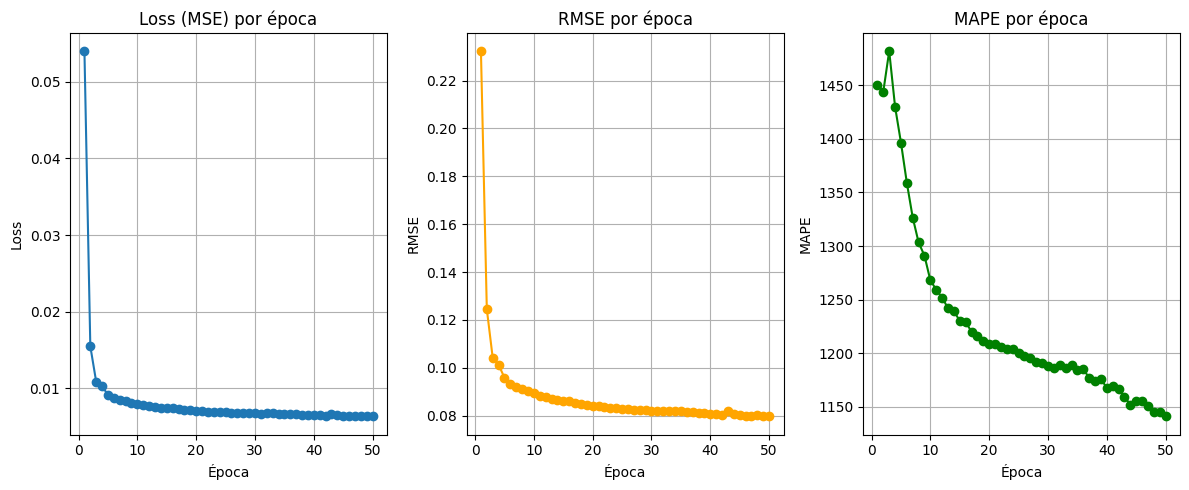

In [6]:
import matplotlib.pyplot as plt

# Extraer métricas del historial
loss = history13.history['loss']
rmse = history13.history['root_mean_squared_error']
mape = history13.history['mean_absolute_percentage_error']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o')
plt.title('Loss (MSE) por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange')
plt.title('RMSE por época')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green')
plt.title('MAPE por época')
plt.xlabel('Época')
plt.ylabel('MAPE')
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model13.evaluate(X, y, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 656s 27s/step - loss: 0.0199 - mean_absolute_percentage_error: 944.8154 - root_mean_squared_error: 0.1411
Pérdida (MSE): 0.0199
RMSE: 0.1411
MAPE: 944.8154


Visualización de imagenes

24/24 ━━━━━━━━━━━━━━━━━━━━ 671s 28s/step


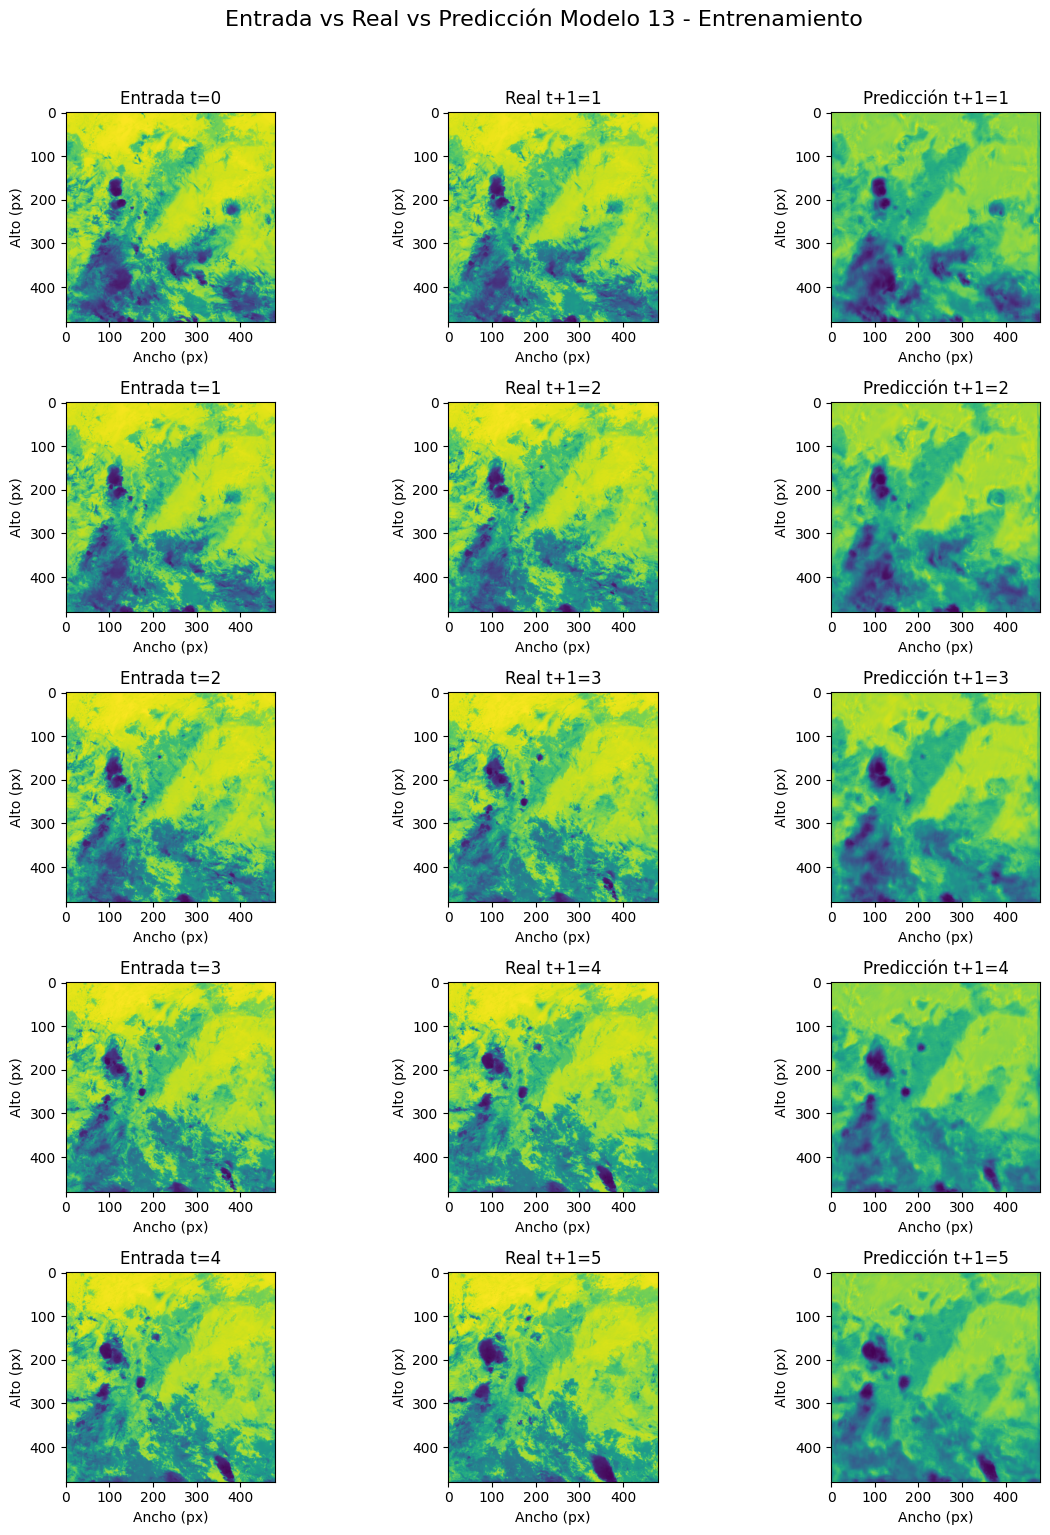

In [8]:
# Genera las predicciones
y_pred13 = model13.predict(X)

# Seleccionar el último frame de la secuencia (t) como entrada para visualizar,
# ya que X tiene forma (N, timesteps, H, W, C) y mostrar_resultados espera (N, H, W, C)
mostrar_resultados(
    X[:, -1, ...],  # último timestep
    y,
    y_pred13,
    n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 13 - Entrenamiento",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

Validación

In [15]:
# Directorio original y reducido para validación
d_feb_1s = 'E:/bandas/banda13/feb_01_07_1s'
d_feb_1s_red = 'E:/bandas/banda13/feb_01_07_1s_red'

# Llamar a la función para redimensionar imágenes
resize_npy_images(d_feb_1s, d_feb_1s_red, new_size=(480, 480))

# Cargar imágenes de validación
file_list_val = sorted([f for f in os.listdir(d_feb_1s_red) if f.endswith('.npy')])
print(f"Procesando {len(file_list_val)} imágenes para validación")

images_val = [np.load(os.path.join(d_feb_1s_red, f)) for f in file_list_val]

# Normalización simple de imágenes de validación
images_val = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images_val]
images_val = [np.clip(img, 0, 1) for img in images_val]

# Parámetro de secuencia temporal (debe ser el mismo que en entrenamiento)
timesteps = 3

# Construir secuencias para validación: X_seq_val (N, timesteps, H, W, C), y_seq_val (N, H, W, C)
X_base_val = np.array(images_val)[..., np.newaxis]  # (num_imgs_val, H, W, C)
y_base_val = X_base_val.copy()  # y_base_val igual a X_base_val

N_seq_val = X_base_val.shape[0] - timesteps
X_seq_val = np.array([X_base_val[i:i+timesteps] for i in range(N_seq_val)])  # (N_seq_val, timesteps, H, W, C)
y_seq_val = y_base_val[timesteps:]  # (N_seq_val, H, W, C)

print(f"Forma de X_seq_val: {X_seq_val.shape}")  # (N_seq_val, timesteps, H, W, C)
print(f"Forma de y_seq_val: {y_seq_val.shape}")  # (N_seq_val, H, W, C)

Procesando 167 imágenes para validación
Forma de X_seq_val: (164, 3, 480, 480, 1)
Forma de y_seq_val: (164, 480, 480, 1)


Metricas de validación

In [16]:
# Ahora puedes evaluar el modelo
loss, rmse, mape = model13.evaluate(X_seq_val, y_seq_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 132s 22s/step - loss: 0.0262 - mean_absolute_percentage_error: 741.5059 - root_mean_squared_error: 0.1617
Pérdida (MSE): 0.0262
RMSE: 0.1617
MAPE: 741.5059


Visualización de imagenes con conjunto de validación

6/6 ━━━━━━━━━━━━━━━━━━━━ 139s 23s/step


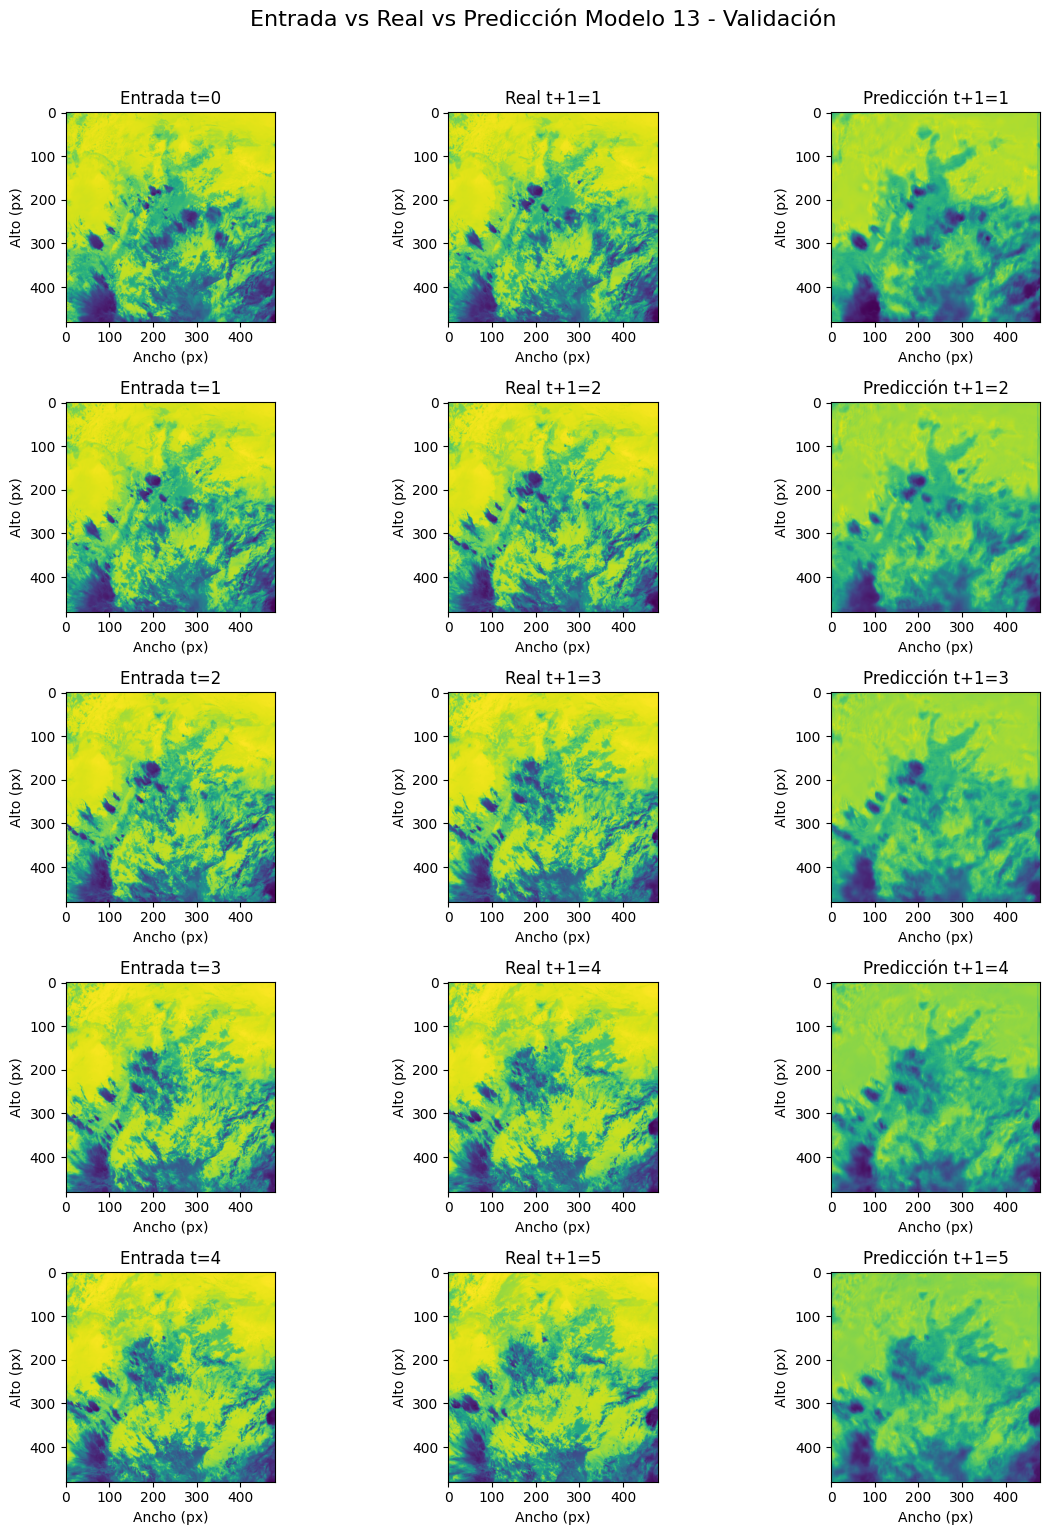

In [18]:
y_pred13_val = model13.predict(X_seq_val)  # Genera las predicciones usando X_seq_val
mostrar_resultados(
    X_seq_val[:, -1, :, :, :],  # Toma solo el último timestep de la secuencia de entrada
    y_seq_val,                   # Valores reales
    y_pred13_val,                # Predicciones
    n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 13 - Validación",
    xlabel="Ancho (px)", 
    ylabel="Alto (px)"
)

RESUMEN DE MÉTRICAS
Entrenamiento - Loss final: 0.0063, RMSE final: 0.0797, MAPE final: 1140.8373
Validación    - Loss: 0.0262, RMSE: 0.1617, MAPE: 741.5059


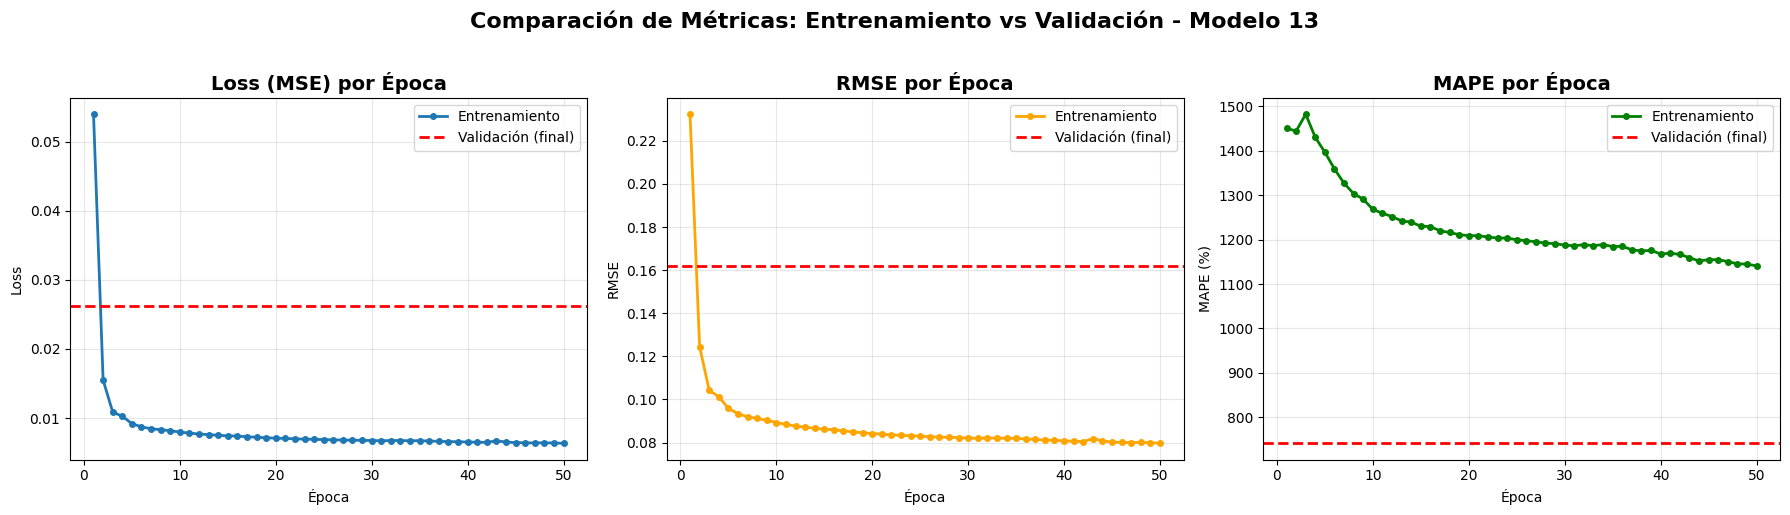

In [19]:
# =============================================================================
# EXTRAER MÉTRICAS DE ENTRENAMIENTO
# =============================================================================

# Extraer métricas de entrenamiento del historial
loss = history13.history['loss']
rmse = history13.history['root_mean_squared_error']
mape = history13.history['mean_absolute_percentage_error']
epochs = range(1, len(loss) + 1)

# =============================================================================
# OBTENER MÉTRICAS DE VALIDACIÓN
# =============================================================================

# Evaluar el modelo en el conjunto de validación (usando las variables correctas)
loss_val, rmse_val, mape_val = model13.evaluate(X_seq_val, y_seq_val, verbose=0)

print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(f"Entrenamiento - Loss final: {loss[-1]:.4f}, RMSE final: {rmse[-1]:.4f}, MAPE final: {mape[-1]:.4f}")
print(f"Validación    - Loss: {loss_val:.4f}, RMSE: {rmse_val:.4f}, MAPE: {mape_val:.4f}")
print("=" * 50)

# =============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# =============================================================================

plt.figure(figsize=(18, 5))

# Gráfico 1: Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento', linewidth=2, markersize=4)
plt.axhline(y=loss_val, color='r', linestyle='--', linewidth=2, label='Validación (final)')
plt.title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: RMSE
plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento', linewidth=2, markersize=4)
plt.axhline(y=rmse_val, color='red', linestyle='--', linewidth=2, label='Validación (final)')
plt.title('RMSE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: MAPE
plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento', linewidth=2, markersize=4)
plt.axhline(y=mape_val, color='red', linestyle='--', linewidth=2, label='Validación (final)')
plt.title('MAPE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Comparación de Métricas: Entrenamiento vs Validación - Modelo 13', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()